# MENTAL HEALTH REDDIT EMOTION INFERENCE

Apply trained Mental-BERT model with optimized thresholds to 40K+ Reddit mental health posts.

Optimized for A100 GPU + 120GB RAM with batch processing.

## SETUP

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers torch

import json
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

# Paths
BASE_DIR = Path("/content/drive/MyDrive/mental_health_research_V2")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models" / "mental_bert_goemotions"
RESULTS_DIR = BASE_DIR / "results" / "reddit_inference"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Mounted at /content/drive
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 79.3 GB


## LOAD MODEL & OPTIMAL THRESHOLDS

In [3]:
# Emotion labels
emotion_labels = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
    'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

# Validate MODEL_DIR exists
if not MODEL_DIR.exists():
    raise FileNotFoundError(f"Model directory not found: {MODEL_DIR}")

# Find latest Mental-BERT model
model_dirs = sorted(MODEL_DIR.glob("mental_bert_finetuned_*"))
if not model_dirs:
    raise FileNotFoundError("No Mental-BERT model found. Run Mental_BERT_GoEmotions_FineTune.ipynb first.")

model_path = model_dirs[-1]
print(f"Loading model from: {model_path}")

# Load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained(str(model_path))
tokenizer = AutoTokenizer.from_pretrained(str(model_path))

# Validate model output dimensions
if model.config.num_labels != len(emotion_labels):
    raise ValueError(f"Model has {model.config.num_labels} labels but expected {len(emotion_labels)}")

model.to(device)
model.eval()

# Load optimal thresholds
thresholds_file = model_path / "optimal_thresholds.json"
with open(thresholds_file, 'r') as f:
    optimal_thresholds = json.load(f)

# Validate all emotions have thresholds
missing_emotions = set(emotion_labels) - set(optimal_thresholds.keys())
if missing_emotions:
    raise ValueError(f"Missing thresholds for emotions: {missing_emotions}")

print(f"Model loaded successfully with {len(emotion_labels)} emotion classes")
print(f"Optimal thresholds validated: {len(optimal_thresholds)} emotions")

Loading model from: /content/drive/MyDrive/mental_health_research_V2/models/mental_bert_goemotions/mental_bert_finetuned_20251118_162109
Model loaded successfully with 28 emotion classes
Optimal thresholds validated: 28 emotions


## LOAD REDDIT DATA

In [4]:
# Load Reddit dataset
reddit_files = sorted(DATA_DIR.glob("reddit_all_subreddits_preprocessed_*.json"))
if not reddit_files:
    raise FileNotFoundError(f"Reddit dataset not found in {DATA_DIR}")

reddit_file = reddit_files[-1]
print(f"Loading: {reddit_file.name}")

try:
    df_reddit = pd.read_json(reddit_file)
except Exception as e:
    raise ValueError(f"Failed to load JSON file: {e}")

# Verify not empty
if len(df_reddit) == 0:
    raise ValueError("Loaded DataFrame is empty")

print(f"\nLoaded {len(df_reddit):,} Reddit posts")

# Verify text_light exists
if 'text_light' not in df_reddit.columns:
    raise ValueError("text_light column not found in dataset")

# Basic stats
print(f"Categories: {df_reddit['category'].nunique()}")
print(f"Subreddits: {df_reddit['subreddit'].nunique()}")

Loading: reddit_all_subreddits_preprocessed_20250821_175216.json

Loaded 40,745 Reddit posts
Categories: 10
Subreddits: 18


## CUSTOM DATASET FOR BATCH PROCESSING

In [5]:
def create_chunks(text, tokenizer, max_length=510, overlap=50):
    """
    Split text into overlapping chunks for posts longer than max_length.

    Args:
        text: Input text to chunk
        tokenizer: Tokenizer to use
        max_length: Maximum tokens per chunk (default 510 to account for special tokens)
        overlap: Number of overlapping tokens between chunks

    Returns:
        List of text chunks
    """
    # Tokenize without special tokens to get actual content length
    tokens = tokenizer.encode(text, add_special_tokens=False)

    # If text fits in single chunk, return as-is
    if len(tokens) <= max_length:
        return [text]

    # Create overlapping chunks
    chunks = []
    step = max_length - overlap

    for i in range(0, len(tokens), step):
        chunk_tokens = tokens[i:i + max_length]

        # Skip if chunk is too small (< 10 tokens)
        if len(chunk_tokens) < 10:
            break

        # Decode chunk back to text
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        chunks.append(chunk_text)

        # Stop if we've covered all tokens
        if i + max_length >= len(tokens):
            break

    return chunks

print("Chunking function defined")

Chunking function defined


In [6]:
class RedditEmotionDataset(Dataset):
    """Dataset for batch processing Reddit posts"""

    def __init__(self, texts, tokenizer, max_length=512):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.empty_indices = []

        # Pre-identify empty texts
        for idx, text in enumerate(texts):
            if pd.isna(text) or len(str(text).strip()) == 0:
                self.empty_indices.append(idx)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        # Handle empty or invalid text
        if pd.isna(text) or len(str(text).strip()) == 0:
            text = ""  # Empty string, will be handled by tokenizer

        # Tokenize (will truncate at max_length)
        encoding = self.tokenizer(
            str(text),
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

print("Dataset class defined")

Dataset class defined


In [7]:
# Pre-process: Create chunks for long posts
print("Creating chunks for long posts...")
all_chunks = []
post_to_chunks = {}

for idx, text in enumerate(tqdm(df_reddit['text_light'], desc="Chunking")):
    chunks = create_chunks(str(text), tokenizer, max_length=510, overlap=50)
    start_chunk_idx = len(all_chunks)
    post_to_chunks[idx] = list(range(start_chunk_idx, start_chunk_idx + len(chunks)))
    all_chunks.extend(chunks)

print(f"Created {len(all_chunks):,} chunks from {len(df_reddit):,} posts")
multi_chunk_posts = sum(1 for chunks in post_to_chunks.values() if len(chunks) > 1)
print(f"Posts with multiple chunks: {multi_chunk_posts:,}")

# Create dataset with all chunks
reddit_dataset = RedditEmotionDataset(
    texts=all_chunks,
    tokenizer=tokenizer,
    max_length=512
)

# Track empty texts
empty_text_indices = set(reddit_dataset.empty_indices)
print(f"Found {len(empty_text_indices)} empty chunks")

# Optimized for A100 + 120GB RAM
BATCH_SIZE = 512  # Increased from 64 for A100 utilization

dataloader = DataLoader(
    reddit_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=12,  # Increased from 2 for faster data loading
    pin_memory=True,
    prefetch_factor=4,  # Prefetch 4 batches per worker
    persistent_workers=True  # Keep workers alive between epochs
)

print(f"Processing {len(all_chunks):,} chunks in batches of {BATCH_SIZE}")
print(f"Total batches: {len(dataloader):,}")

# Pre-allocate numpy array for all chunks
chunk_probs = np.zeros((len(all_chunks), len(emotion_labels)), dtype=np.float32)
failed_batches = []
current_idx = 0

# Import for mixed precision
from torch.cuda.amp import autocast

# Batch inference with FP16 mixed precision
with torch.no_grad(), autocast():  # FP16 for 2x speedup on A100
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Inference")):
        try:
            # Move to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Get probabilities
            probabilities = torch.sigmoid(outputs.logits).cpu().numpy()

            # Store results
            batch_size = len(probabilities)
            chunk_probs[current_idx:current_idx+batch_size] = probabilities
            current_idx += batch_size

        except Exception as e:
            print(f"\nError in batch {batch_idx}: {e}")
            failed_batches.append(batch_idx)
            batch_size = len(batch['input_ids'])
            chunk_probs[current_idx:current_idx+batch_size] = 0
            current_idx += batch_size

# Aggregate chunks back to posts using mean averaging
print("\nAggregating chunk predictions...")
all_emotion_probs = np.zeros((len(df_reddit), len(emotion_labels)), dtype=np.float32)

for post_idx, chunk_indices in tqdm(post_to_chunks.items(), desc="Aggregating"):
    # Get probabilities for all chunks of this post
    post_chunk_probs = chunk_probs[chunk_indices]
    # Mean average across chunks
    all_emotion_probs[post_idx] = post_chunk_probs.mean(axis=0)

# Clear GPU cache
torch.cuda.empty_cache()

print(f"\nInference complete! Shape: {all_emotion_probs.shape}")
print(f"Expected shape: ({len(df_reddit)}, {len(emotion_labels)})")

if failed_batches:
    print(f"\nWARNING: {len(failed_batches)} batches failed: {failed_batches}")

# Verify shapes match
assert all_emotion_probs.shape[0] == len(df_reddit), "Shape mismatch between predictions and dataframe!"
assert all_emotion_probs.shape[1] == len(emotion_labels), "Emotion dimension mismatch!"

Creating chunks for long posts...


Chunking:   0%|          | 0/40745 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (918 > 512). Running this sequence through the model will result in indexing errors


Created 44,975 chunks from 40,745 posts
Posts with multiple chunks: 3,196
Found 0 empty chunks
Processing 44,975 chunks in batches of 512
Total batches: 88


/tmp/ipython-input-3739340373.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():  # FP16 for 2x speedup on A100


Inference:   0%|          | 0/88 [00:00<?, ?it/s]


Aggregating chunk predictions...


Aggregating:   0%|          | 0/40745 [00:00<?, ?it/s]


Inference complete! Shape: (40745, 28)
Expected shape: (40745, 28)


## EXTRACT EMOTION FEATURES (OPTIMIZED SINGLE PASS)

In [8]:
# Extract all features in single pass (optimized)
emotion_probs_list = []
top_3_emotions = []
dominant_emotions = []
predicted_labels = []
is_empty_flags = []

for idx, probs in enumerate(all_emotion_probs):
    # Track if this was an empty text
    is_empty = idx in empty_text_indices
    is_empty_flags.append(is_empty)

    # 1. Emotion probabilities dict
    probs_dict = {emotion: float(prob) for emotion, prob in zip(emotion_labels, probs)}
    emotion_probs_list.append(probs_dict)

    # 2. Top 3 emotions
    top_3_idx = np.argsort(probs)[-3:][::-1]
    top_3 = [(emotion_labels[idx], float(probs[idx])) for idx in top_3_idx]
    top_3_emotions.append(top_3)

    # 3. Dominant emotion
    dominant_idx = np.argmax(probs)
    dominant_emotions.append(emotion_labels[dominant_idx])

    # 4. Predicted labels using optimal thresholds
    labels = [emotion for emotion, prob in zip(emotion_labels, probs)
              if prob >= optimal_thresholds[emotion]]
    predicted_labels.append(labels)

# Add to dataframe
df_reddit['emotion_probabilities'] = emotion_probs_list
df_reddit['top_3_emotions'] = top_3_emotions
df_reddit['dominant_emotion'] = dominant_emotions
df_reddit['predicted_emotion_labels'] = predicted_labels
df_reddit['is_empty_text'] = is_empty_flags

print("Emotion features extracted:")
print(f"  - emotion_probabilities: Dict of all {len(emotion_labels)} emotions")
print(f"  - top_3_emotions: Top 3 emotions with probabilities")
print(f"  - dominant_emotion: Single highest probability emotion")
print(f"  - predicted_emotion_labels: Binary labels using optimal thresholds")
print(f"  - is_empty_text: Flag for empty/invalid texts ({sum(is_empty_flags)} posts)")
print(f"\nSample (non-empty texts):")
print(df_reddit[~df_reddit['is_empty_text']][['dominant_emotion', 'top_3_emotions']].head(3))

Emotion features extracted:
  - emotion_probabilities: Dict of all 28 emotions
  - top_3_emotions: Top 3 emotions with probabilities
  - dominant_emotion: Single highest probability emotion
  - predicted_emotion_labels: Binary labels using optimal thresholds
  - is_empty_text: Flag for empty/invalid texts (0 posts)

Sample (non-empty texts):
  dominant_emotion                                     top_3_emotions
0      nervousness  [(nervousness, 0.496337890625), (sadness, 0.46...
1          sadness  [(sadness, 0.58642578125), (grief, 0.530273437...
2        annoyance  [(annoyance, 0.3759765625), (disappointment, 0...


## SAVE RESULTS

In [9]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = RESULTS_DIR / f"reddit_emotions_predicted_{timestamp}.json"

try:
    df_reddit.to_json(output_file, orient='records', indent=2)
    print(f"Results saved to: {output_file}")
    print(f"Total posts: {len(df_reddit):,}")
    print(f"File size: {output_file.stat().st_size / 1024 / 1024:.1f} MB")
except Exception as e:
    print(f"Error saving results: {e}")
    # Fallback: save without indent (smaller file)
    output_file_backup = RESULTS_DIR / f"reddit_emotions_predicted_{timestamp}_backup.json"
    df_reddit.to_json(output_file_backup, orient='records')
    print(f"Backup saved to: {output_file_backup}")

Results saved to: /content/drive/MyDrive/mental_health_research_V2/results/reddit_inference/reddit_emotions_predicted_20251118_194626.json
Total posts: 40,745
File size: 231.4 MB


## MINIMAL EDA - DOMINANT EMOTION DISTRIBUTION

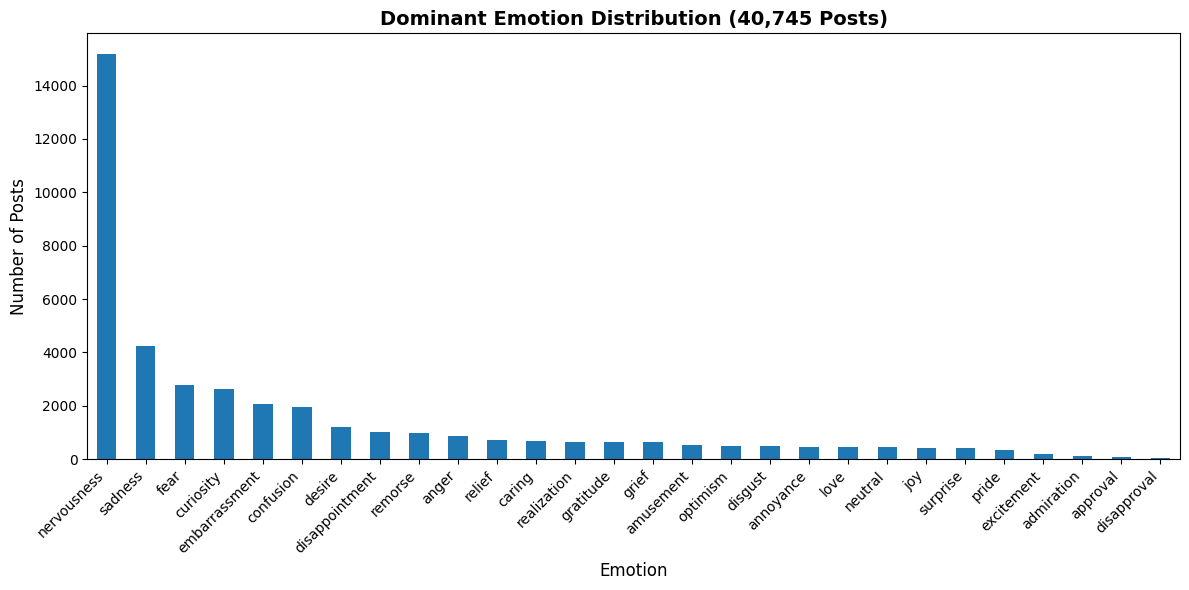


Dominant Emotion Counts (Valid Posts Only):
dominant_emotion
nervousness       15195
sadness            4231
fear               2767
curiosity          2643
embarrassment      2047
confusion          1964
desire             1187
disappointment     1010
remorse             985
anger               882
relief              725
caring              666
realization         660
gratitude           651
grief               647
amusement           530
optimism            508
disgust             496
annoyance           461
love                451
neutral             439
joy                 408
surprise            404
pride               345
excitement          183
admiration          123
approval             84
disapproval          53
Name: count, dtype: int64


In [10]:
# Exclude empty texts from analysis
df_valid = df_reddit[~df_reddit['is_empty_text']]

dominant_counts = df_valid['dominant_emotion'].value_counts()

plt.figure(figsize=(12, 6))
dominant_counts.plot(kind='bar')
plt.title(f'Dominant Emotion Distribution ({len(df_valid):,} Posts)', fontsize=14, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"dominant_emotion_distribution_{timestamp}.png", dpi=150)
plt.show()

print("\nDominant Emotion Counts (Valid Posts Only):")
print(dominant_counts)

## TOP 3 EMOTION FREQUENCY

In [11]:
# Count how often each emotion appears in top 3 (valid posts only)
top_3_freq = {emotion: 0 for emotion in emotion_labels}

for top_3 in df_valid['top_3_emotions']:
    for emotion, _ in top_3:
        top_3_freq[emotion] += 1

top_3_df = pd.DataFrame([
    {'emotion': emotion, 'count': count, 'percentage': (count/len(df_valid))*100}
    for emotion, count in top_3_freq.items()
]).sort_values('count', ascending=False)

print("\nTop 3 Emotion Frequency:")
print(top_3_df.to_string(index=False))


Top 3 Emotion Frequency:
       emotion  count  percentage
   nervousness  26200   64.302368
       sadness  16789   41.205056
          fear  11792   28.940974
disappointment   8843   21.703276
     confusion   8553   20.991533
 embarrassment   5979   14.674193
     curiosity   5927   14.546570
   realization   3723    9.137317
        desire   3577    8.778991
         grief   3143    7.713830
       remorse   3019    7.409498
     annoyance   2540    6.233894
      optimism   2435    5.976193
        relief   2298    5.639956
        caring   2138    5.247270
       disgust   2079    5.102467
         anger   1915    4.699963
           joy   1693    4.155111
       neutral   1436    3.524359
     gratitude   1296    3.180758
      surprise   1293    3.173396
     amusement   1093    2.682538
          love   1011    2.481286
      approval    961    2.358572
    excitement    939    2.304577
         pride    667    1.637011
    admiration    590    1.448030
   disapproval    306 